# DAY 1 EDA - ESS 배터리 수명 예측 (MIT-Stanford, Severson et al. 2019)
Batch 1 / 2 / 3 각각에 대해 EDA 질문 5개를 수행하고 배치 간 특징을 비교한다.

**팀 합의 기준 (최종)**
- 인덱스: summary / Qdlin 배열 index j = cycle − 1 (j=0의 `cycle` 필드 = 1) → cycle 10 = j9, cycle 100 = j99
- b1 c0\~c4: 수명 미관측(EOL 미도달)이라 **기본 제외**, 원논문 보정 수명을 넣은 경우는 **민감도 분석**으로 따로 보고
- b3: EOL 미도달 2셀(c23, c32)만 제거. 원논문 노이즈 채널 4셀(c2, c37, c42, c43)은 스파이크 점검에 걸리지 않아 유지 → 44셀
- DAY 1에서는 Test 배치에 대한 모델 평가를 하지 않는다 (배치별 기술 통계만)

원본 .mat 로드는 `load_data.py` → `data/cells_raw.pkl` (h5py로 summary + cycle 1\~120의 Qdlin만 선택 로드)

In [1]:
import pickle, re, json, numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
BC = {'b1': '#2a6fdb', 'b2': '#e8871e', 'b3': '#2ca25f'}; B = ['b1', 'b2', 'b3']
EOL = 0.88; DATA = '../data'; FIG = '../figures/eda'   # 노트북은 notebooks/에서 실행
import os; os.makedirs(FIG, exist_ok=True)
raw = pickle.load(open(f'{DATA}/cells_raw.pkl', 'rb'))
def save(n):
    plt.savefig(f'{FIG}/{n}.png', dpi=170, bbox_inches='tight'); plt.show()
def r_(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float); m = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[m], y[m])[0] if m.sum() > 2 else np.nan
ST = {}   # 장표용 수치 모음

## 0. 데이터 정제
- (1) 다른 실험 프로토콜(VarCharge, SLOWCYCLE) 제거 — cycle_life 기록 없음
- (2) EOL(0.88Ah) 미도달 = 수명 미관측(우측 중도절단) 제거 — b1 c0\~c4는 민감도 분석용으로 따로 보관
- 단발성 QD 스파이크는 셀 제거 대신 median filter(k=5)로 보정, IR = 0(측정 누락)은 NaN

In [2]:
# sanity check: 인덱스 규칙
s0 = raw['b1'][0]['summary']
print('b1c0 summary  j=0..3 의 cycle 필드:', s0['cycle'][:4], ' QD:', np.round(s0['QDischarge'][:4], 3))
PAPER_B1_ADD = {'b1c0': 662, 'b1c1': 981, 'b1c2': 1060, 'b1c3': 208, 'b1c4': 482}   # 원논문 코드의 수명 보정값
PAPER_B3_NOISY = []   # 원논문 노이즈 채널 4셀(c2, c37, c42, c43)은 스파이크 점검(30mAh 초과)에 걸리지 않아 유지, c23·c32는 EOL 미도달로 제거
rows = []
for t in B:
    for c in raw[t]:
        s = c['summary']; qd = s['QDischarge']
        q_s = qd.copy(); q_s[1:] = medfilt(qd[1:], 5); c['qd_s'] = q_s
        reached = (q_s[1:] <= EOL + 0.0035).any()
        reason = ''
        if 'VarCharge' in c['policy'] or 'SLOWCYCLE' in c['policy']:
            reason = '다른 실험 프로토콜 (cycle_life 없음)'
        elif c['key'] in PAPER_B3_NOISY:
            reason = '원논문 노이즈 채널 (2차 테스트셋 40셀 기준)'
        elif not np.isfinite(c['cycle_life_raw']) or not reached:
            reason = 'EOL 미도달 (수명 미관측)'
        spike = np.abs(qd[1:101] - medfilt(qd[1:101], 5)).max() * 1000
        rows.append(dict(batch=t, key=c['key'], policy=c['policy'], life_raw=c['cycle_life_raw'], n=len(qd),
                         QD_last=round(qd[-1], 3), spike_max_mAh=round(spike, 1), reason=reason))
qc = pd.DataFrame(rows)
print(qc[qc.reason != ''][['batch', 'key', 'policy', 'life_raw', 'QD_last', 'reason']].to_string())
cnt = pd.DataFrame({'원본': qc.groupby('batch').size(), '제거': qc[qc.reason != ''].groupby('batch').size(),
                    '최종': qc[qc.reason == ''].groupby('batch').size()}).fillna(0).astype(int)
print(cnt)
ST['count'] = cnt.to_dict()
ST['spike_cells'] = qc[(qc.spike_max_mAh > 30) & (qc.reason == '')][['key', 'spike_max_mAh']].values.tolist()
ST['censored_b1'] = qc[(qc.batch == 'b1') & (qc.reason.str.startswith('EOL'))][['key', 'policy', 'life_raw', 'QD_last']].to_dict('records')
qc.to_csv(f'{DATA}/data_cleaning_log.csv', index=False, encoding='utf-8-sig')
keep = set(qc[qc.reason == ''].key)
cells = [c for t in B for c in raw[t] if c['key'] in keep]
for c in cells: c['life'] = c['cycle_life_raw']
# 민감도 분석용: b1 c0~c4 + 원논문 보정 수명
sens = [c for c in raw['b1'] if c['key'] in PAPER_B1_ADD]
for c in sens: c['life'] = c['cycle_life_raw'] + PAPER_B1_ADD[c['key']]

b1c0 summary  j=0..3 의 cycle 필드: [1. 2. 3. 4.]  QD: [0.    1.071 1.072 1.073]
    batch    key                       policy  life_raw  QD_last                      reason
0      b1   b1c0               3.6C(80%)-3.6C    1190.0    1.026            EOL 미도달 (수명 미관측)
1      b1   b1c1               3.6C(80%)-3.6C    1179.0    1.038            EOL 미도달 (수명 미관측)
2      b1   b1c2               3.6C(80%)-3.6C    1177.0    1.043            EOL 미도달 (수명 미관측)
3      b1   b1c3                   4C(80%)-4C    1226.0    0.971            EOL 미도달 (수명 미관측)
4      b1   b1c4                   4C(80%)-4C    1227.0    1.022            EOL 미도달 (수명 미관측)
8      b1   b1c8               5.4C(40%)-3.6C     879.0    0.969            EOL 미도달 (수명 미관측)
10     b1  b1c10                 5.4C(50%)-3C     906.0    0.961            EOL 미도달 (수명 미관측)
12     b1  b1c12               5.4C(50%)-3.6C     902.0    0.913            EOL 미도달 (수명 미관측)
13     b1  b1c13               5.4C(50%)-3.6C     897.0    0.923            EOL 미도달 (

## 피처 테이블 (cycle 2\~100 정보만 사용)
| 그룹 | 피처 | 의미 |
|---|---|---|
| ΔQ(V) | dQ_logvar, dQ_logmin, dQ_mean, dQ_skew, dQ_kurt | Q100(V) − Q10(V) 곡선의 형태 |
| 용량 | QD_2, QD_100_m10, QD_slope_2_100, QD_icpt_2_100, QD_slope_91_100 | 초기 용량과 감소 추세 |
| 저항 | IR_2, IR_min, IR_100_m2 | 내부 저항 |
| 온도 | Tavg_mean, Tmax_max, Trange_mean | 충방전 발열 |
| 충전 | chargetime_2_6, C1, Q1, C2, avgC_80 | 충전 조건 (avgC_80 = 0→80% SOC 평균 C-rate, 정책 문자열에서 계산) |

In [3]:
PR = re.compile(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C')
def pol(p):
    c1, q1, c2 = map(float, PR.search(p).groups())
    t = min(q1, 80) / 100 / c1 + max(0, 80 - q1) / 100 / c2      # 0→80% 충전 시간(h)
    return dict(C1=c1, Q1=q1, C2=c2, avgC_80=0.8 / t, newstruct=int('newstructure' in p))
def feats(c):
    s = c['summary']; q = c['qdlin']; dq = q[99] - q[9]          # cycle 100 − cycle 10
    j = np.arange(2, 101).astype(float); qd = c['qd_s'][1:100]     # cycle 2..100
    ir = s['IR'][1:100]; ir = np.where(ir > 0, ir, np.nan)
    p1 = np.polyfit(j, qd, 1); p2 = np.polyfit(j[-10:], qd[-10:], 1)
    f = dict(batch=c['batch'], key=c['key'], policy=c['policy'], life=c['life'], log_life=np.log10(c['life']),
             dQ_logvar=np.log10(np.var(dq)), dQ_logmin=np.log10(abs(dq.min())), dQ_mean=dq.mean() * 1000,
             dQ_skew=skew(dq), dQ_kurt=np.log10(abs(kurtosis(dq))),
             QD_2=qd[0], QD_100_m10=(c['qd_s'][99] - c['qd_s'][9]) * 1000,
             QD_slope_2_100=p1[0] * 1e6, QD_icpt_2_100=p1[1], QD_slope_91_100=p2[0] * 1e6,
             IR_2=ir[0], IR_min=np.nanmin(ir) if np.isfinite(ir).any() else np.nan, IR_100_m2=(ir[-1] - ir[0]) * 1e4,
             Tavg_mean=np.nanmean(s['Tavg'][1:100]), Tmax_max=np.nanmax(s['Tmax'][1:100]),
             Trange_mean=np.nanmean(s['Tmax'][1:100] - s['Tmin'][1:100]),
             chargetime_2_6=np.nanmean(s['chargetime'][1:6]))
    f.update(pol(c['policy'])); return f
F = pd.DataFrame([feats(c) for c in cells])
FS = pd.DataFrame([feats(c) for c in sens])     # 민감도용 5셀
FEATS = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'dQ_kurt', 'QD_2', 'QD_100_m10', 'QD_slope_2_100',
         'QD_icpt_2_100', 'QD_slope_91_100', 'IR_2', 'IR_min', 'IR_100_m2', 'Tavg_mean', 'Tmax_max', 'Trange_mean',
         'chargetime_2_6', 'C1', 'Q1', 'C2', 'avgC_80']
miss = F[FEATS].isna().groupby(F.batch).sum(); print('결측:\n', miss.loc[:, miss.sum() > 0])
ST['missing'] = miss.loc[:, miss.sum() > 0].to_dict()

결측:
        IR_2  IR_min  IR_100_m2
batch                         
b1        0       0          0
b2        6       6          6
b3        0       0          0


## Q1. Cycle Life 분포는 어떻게 생겼는가?

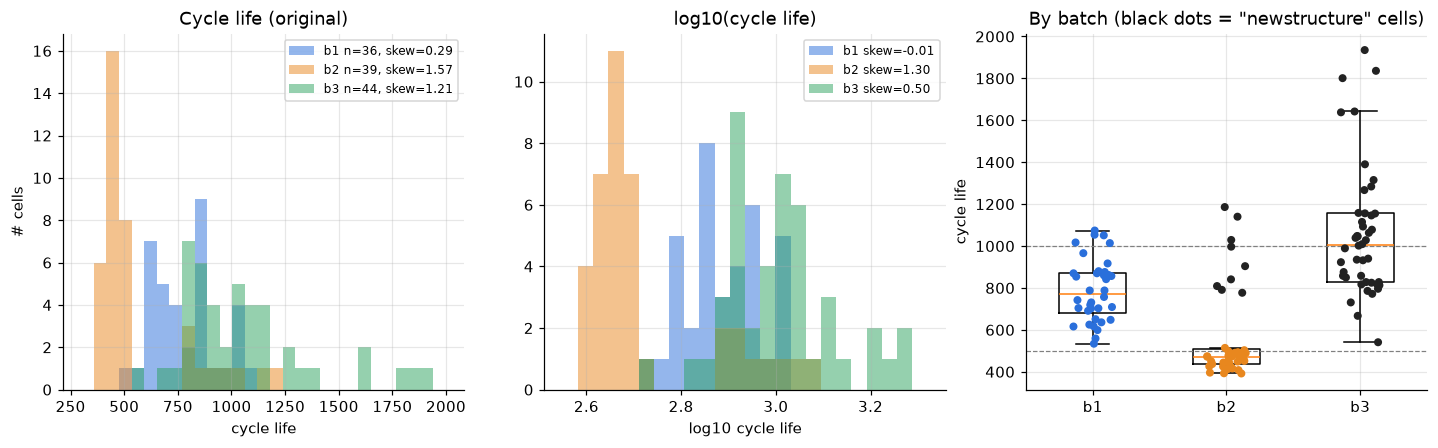

       count    min  median    mean     max  skew  skew_log  long>1000 %  short<500 %  newstruct %
batch                                                                                             
b1        36  534.0   772.0   788.0  1074.0  0.29     -0.01         13.9          0.0          0.0
b2        39  392.0   472.0   566.0  1186.0  1.57      1.30          7.7         71.8         23.1
b3        44  541.0  1006.0  1060.0  1935.0  1.21      0.50         52.3          0.0        100.0
   batch    key                       policy    life  newstruct
0     b2   b2c7  4.8C(80%)-4.8C-newstructure   777.0          1
1     b2   b2c8    5.2C(58%)-4C-newstructure   904.0          1
2     b2   b2c9  5.6C(26%)-4.5C-newstructure   791.0          1
3     b2  b2c32  4.8C(80%)-4.8C-newstructure   809.0          1
4     b2  b2c33    5.2C(58%)-4C-newstructure  1140.0          1
5     b2  b2c34  5.6C(26%)-4.5C-newstructure  1186.0          1
6     b2  b2c43  4.8C(80%)-4.8C-newstructure  1029.0     

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
bins = np.linspace(300, 2000, 30); lb = np.linspace(2.55, 3.32, 25)
for t in B:
    d = F[F.batch == t]
    ax[0].hist(d.life, bins=bins, alpha=.5, color=BC[t], label=f'{t} n={len(d)}, skew={skew(d.life):.2f}')
    ax[1].hist(d.log_life, bins=lb, alpha=.5, color=BC[t], label=f'{t} skew={skew(d.log_life):.2f}')
ax[0].set(title='Cycle life (original)', xlabel='cycle life', ylabel='# cells'); ax[0].legend(fontsize=8)
ax[1].set(title='log10(cycle life)', xlabel='log10 cycle life'); ax[1].legend(fontsize=8)
for i, t in enumerate(B):
    d = F[F.batch == t]; x = i + np.random.RandomState(0).uniform(-.15, .15, len(d))
    ax[2].scatter(x, d.life, c=['#222' if n else BC[t] for n in d.newstruct], s=18, zorder=3)
    ax[2].boxplot(d.life, positions=[i], widths=.5, showfliers=False)
ax[2].axhline(1000, ls='--', c='gray', lw=.8); ax[2].axhline(500, ls='--', c='gray', lw=.8)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(B)
ax[2].set(title='By batch (black dots = "newstructure" cells)', ylabel='cycle life')
save('Q1_cycle_life_dist')
q1 = F.groupby('batch').life.agg(['count', 'min', 'median', 'mean', 'max']).round(0)
q1['skew'] = F.groupby('batch').life.apply(skew).round(2)
q1['skew_log'] = F.groupby('batch').log_life.apply(skew).round(2)
q1['long>1000 %'] = F.groupby('batch').life.apply(lambda x: (x > 1000).mean() * 100).round(1)
q1['short<500 %'] = F.groupby('batch').life.apply(lambda x: (x < 500).mean() * 100).round(1)
q1['newstruct %'] = F.groupby('batch').newstruct.mean().mul(100).round(1)
print(q1); ST['q1'] = q1.reset_index().to_dict('records')
# IQR 이상치 + 배치별 최단 수명 셀
out = []
for t in B:
    d = F[F.batch == t]; q25, q75 = d.life.quantile([.25, .75]); iqr = q75 - q25
    o = d[(d.life < q25 - 1.5 * iqr) | (d.life > q75 + 1.5 * iqr)]
    out += [dict(batch=t, key=r.key, policy=r.policy, life=r.life, newstruct=r.newstruct) for _, r in o.iterrows()]
print(pd.DataFrame(out)); ST['q1_outliers'] = out
short = F.loc[F.groupby('batch').life.idxmin(), ['batch', 'key', 'policy', 'life', 'avgC_80', 'C1', 'C2', 'dQ_logvar']]
short['dQ_logvar_batch_median'] = short.batch.map(F.groupby('batch').dQ_logvar.median())
short['avgC_rank_in_batch'] = [int((F[F.batch == r.batch].avgC_80 > r.avgC_80 + 1e-9).sum() + 1) for _, r in short.iterrows()]
print(short); ST['q1_short'] = short.round(3).to_dict('records')
# 민감도: c0~c4 포함 시 b1
b1s = pd.concat([F[F.batch == 'b1'], FS])
ST['sens_b1'] = dict(n=len(b1s), min=b1s.life.min(), max=b1s.life.max(), median=b1s.life.median(),
                     skew=skew(b1s.life), skew_log=skew(b1s.log_life), r_logvar=r_(b1s.dQ_logvar, b1s.log_life),
                     r_logvar_base=r_(F[F.batch == 'b1'].dQ_logvar, F[F.batch == 'b1'].log_life),
                     lives=FS.life.tolist())
print('민감도 (c0~c4 포함 b1):', ST['sens_b1'])

                           count   mean    min     max
pol_base        newstruct                             
3.6C(30%)-6C    0              2  421.0  416.0   426.0
3.6C(9%)-5C     0              2  394.0  393.0   396.0
4.65C(44%)-5C   0              2  482.0  466.0   499.0
4.65C(69%)-6C   0              2  452.0  444.0   460.0
4.8C(80%)-4.8C  0              5  484.0  437.0   514.0
                1              3  872.0  777.0  1029.0
5.2C(50%)-4.25C 0              5  454.0  424.0   474.0
5.2C(58%)-4C    0              4  478.0  452.0   493.0
                1              3  962.0  841.0  1140.0
5.6C(26%)-4.5C  0              6  448.0  412.0   491.0
                1              3  991.0  791.0  1186.0
6C(60%)-3C      0              2  400.0  392.0   408.0
                  n  life_med  logvar_med  IR2_med
batch newstruct                                   
b1    0          36     772.5     -3.7865   0.0167
b2    0          30     451.0     -3.4556   0.0171
      1           9     90

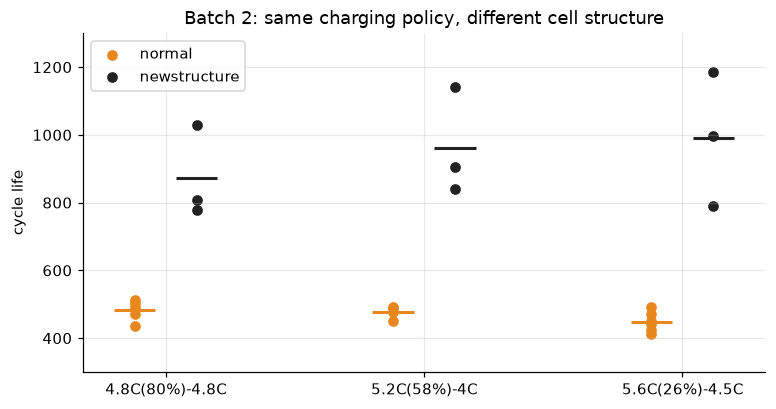

In [5]:
# 같은 정책, 다른 셀 구조 (b2) + 배치별 구조 비율
F['pol_base'] = F.policy.str.replace('-newstructure', '')
cmp = F[F.batch == 'b2'].groupby(['pol_base', 'newstruct']).life.agg(['count', 'mean', 'min', 'max']).round(0)
print(cmp); ST['q1_newstruct'] = cmp.reset_index().to_dict('records')
ns = F.groupby(['batch', 'newstruct']).agg(n=('life', 'size'), life_med=('life', 'median'), logvar_med=('dQ_logvar', 'median'),
                                           IR2_med=('IR_2', 'median')).round(4)
print(ns); ST['q1_ns_table'] = ns.reset_index().to_dict('records')
fig, ax = plt.subplots(figsize=(8, 4))
pb = sorted(F[(F.batch == 'b2') & (F.newstruct == 1)].pol_base.unique())
for i, p in enumerate(pb):
    for nsf, col, off in ((0, BC['b2'], -.12), (1, '#222', .12)):
        d = F[(F.batch == 'b2') & (F.pol_base == p) & (F.newstruct == nsf)]
        ax.scatter([i + off] * len(d), d.life, c=col, s=36, label=('normal' if nsf == 0 else 'newstructure') if i == 0 else None)
        ax.hlines(d.life.mean(), i + off - .08, i + off + .08, color=col, lw=2)
ax.set_xticks(range(len(pb))); ax.set_xticklabels(pb); ax.legend()
ax.set(title='Batch 2: same charging policy, different cell structure', ylabel='cycle life', ylim=(300, 1300))
save('Q1_newstructure_b2')

## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

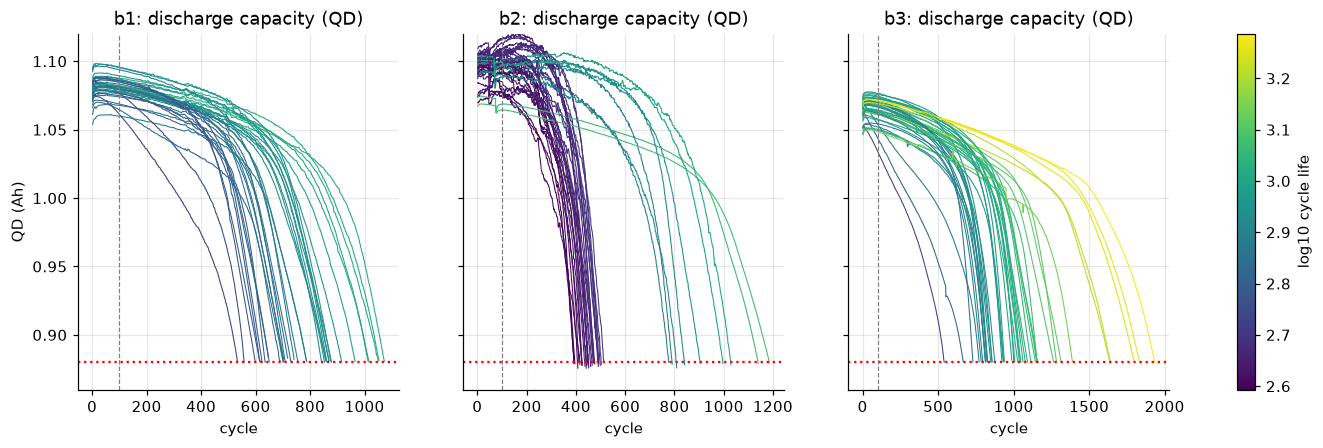

       knee_med  ratio_q25  ratio_med  ratio_q75  pre_med  post_med  accel_med
batch                                                                         
b1        579.0       0.74       0.75       0.77   -72.46   -795.23      10.51
b2        343.0       0.72       0.75       0.77  -103.70  -1335.55      11.38
b3        820.0       0.78       0.79       0.83   -61.08   -684.51       9.98
       50%   min   max
batch                 
b1    -1.3 -14.4   1.8
b2     0.4 -20.4  11.2
b3    -1.1 -18.7   0.3 {'b1': np.float64(0.5541388198145784), 'b2': np.float64(-0.24430316879125452), 'b3': np.float64(0.4406667978109926), 'all': np.float64(-0.11595946291067022)} {'b1': np.float64(0.15658710913885576), 'b2': np.float64(-0.21660614816832754), 'b3': np.float64(0.17051544025664586)} 70.0


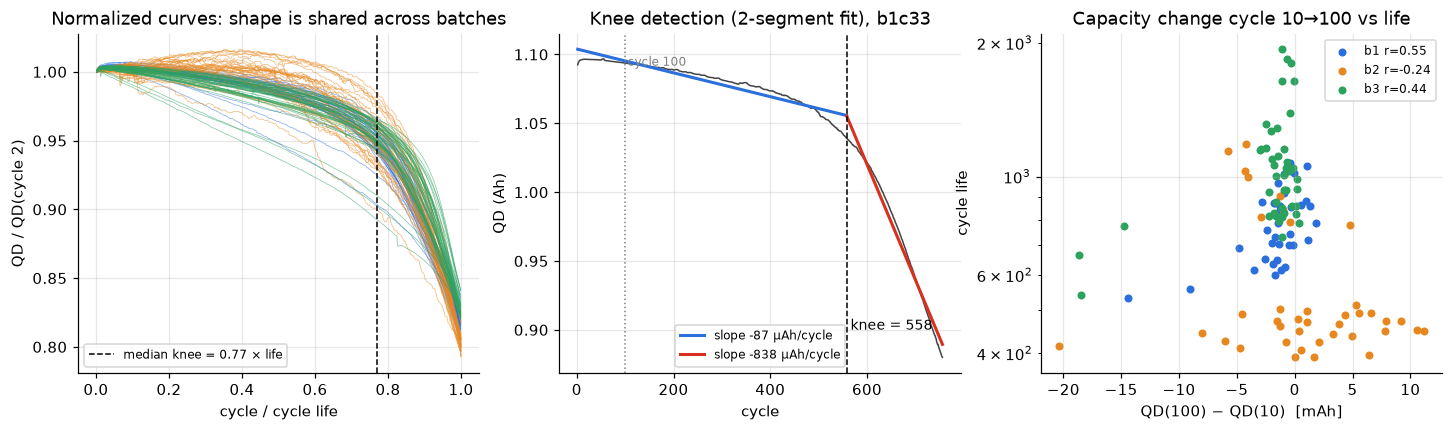

In [6]:
norm = plt.Normalize(F.log_life.min(), F.log_life.max()); cm = plt.cm.viridis
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for a, t in zip(ax, B):
    for c in [c for c in cells if c['batch'] == t]:
        n = min(int(c['life']), len(c['qd_s']))
        a.plot(np.arange(2, n + 1), c['qd_s'][1:n], color=cm(norm(np.log10(c['life']))), lw=.7)
    a.axhline(EOL, c='r', ls=':'); a.axvline(100, c='gray', ls='--', lw=.8)
    a.set(title=f'{t}: discharge capacity (QD)', xlabel='cycle', ylim=(.86, 1.12))
ax[0].set_ylabel('QD (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm), ax=ax, label='log10 cycle life'); save('Q2_QD_curves')

def knee(x, y):
    best, bs = None, np.inf
    for k in range(int(len(x) * .2), int(len(x) * .97), 3):
        sse = 0
        for xx, yy in ((x[:k], y[:k]), (x[k:], y[k:])):
            p = np.polyfit(xx, yy, 1); sse += ((np.polyval(p, xx) - yy) ** 2).sum()
        if sse < bs: best, bs = k, sse
    return x[best], np.polyfit(x[:best], y[:best], 1)[0], np.polyfit(x[best:], y[best:], 1)[0]
K = []
for c in cells:
    n = min(int(c['life']), len(c['qd_s'])); x = np.arange(2, n + 1).astype(float); y = c['qd_s'][1:n]
    kc, s1, s2 = knee(x, y)
    K.append(dict(key=c['key'], batch=c['batch'], life=c['life'], knee=kc, ratio=kc / c['life'], slope_pre=s1 * 1e6, slope_post=s2 * 1e6))
K = pd.DataFrame(K); K['accel'] = K.slope_post / K.slope_pre
F = F.merge(K[['key', 'knee', 'slope_pre', 'slope_post']], on='key')
kq = K.groupby('batch').agg(knee_med=('knee', 'median'), ratio_q25=('ratio', lambda x: x.quantile(.25)), ratio_med=('ratio', 'median'),
                            ratio_q75=('ratio', lambda x: x.quantile(.75)), pre_med=('slope_pre', 'median'),
                            post_med=('slope_post', 'median'), accel_med=('accel', 'median')).round(2)
print(kq); ST['q2_knee'] = kq.reset_index().to_dict('records'); ST['q2_accel_all'] = K.accel.median()
fade = F.groupby('batch').QD_100_m10.describe()[['50%', 'min', 'max']].round(1)
ST['q2_fade'] = fade.reset_index().to_dict('records')
ST['q2_r_fade'] = {t: r_(F[F.batch == t].QD_100_m10, F[F.batch == t].log_life) for t in B}
ST['q2_r_fade']['all'] = r_(F.QD_100_m10, F.log_life)
ST['q2_r_QD2'] = {t: r_(F[F.batch == t].QD_2, F[F.batch == t].log_life) for t in B}
ST['q2_b2_rise_pct'] = float((F[(F.batch == 'b2') & (F.newstruct == 0)].QD_100_m10 > 0).mean() * 100)
print(fade, ST['q2_r_fade'], ST['q2_r_QD2'], ST['q2_b2_rise_pct'])
# 예시 셀의 knee 시각화 + 정규화 곡선 + 초기 용량 변화 vs 수명
ex = F[F.batch == 'b1'].iloc[(F[F.batch == 'b1'].life - F[F.batch == 'b1'].life.median()).abs().argsort().iloc[0]]
c_ex = next(c for c in cells if c['key'] == ex.key)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in cells:
    n = min(int(c['life']), len(c['qd_s'])); y = c['qd_s'][1:n]
    ax[0].plot(np.arange(2, n + 1) / c['life'], y / y[0], color=BC[c['batch']], lw=.5, alpha=.55)
ax[0].axvline(K.ratio.median(), c='k', ls='--', lw=1, label=f'median knee = {K.ratio.median():.2f} × life')
ax[0].set(title='Normalized curves: shape is shared across batches', xlabel='cycle / cycle life', ylabel='QD / QD(cycle 2)'); ax[0].legend(fontsize=8)
n = min(int(c_ex['life']), len(c_ex['qd_s'])); x = np.arange(2, n + 1); y = c_ex['qd_s'][1:n]
kc = ex.knee
ax[1].plot(x, y, c='#444', lw=1)
for xs, col in ((x[x <= kc], '#2a6fdb'), (x[x >= kc], '#d7301f')):
    p = np.polyfit(xs, c_ex['qd_s'][xs - 1], 1); ax[1].plot(xs, np.polyval(p, xs), c=col, lw=2,
            label=f'slope {p[0]*1e6:.0f} µAh/cycle')
ax[1].axvline(kc, c='k', ls='--', lw=1); ax[1].axvline(100, c='gray', ls=':', lw=1)
ax[1].text(105, y.max() - .005, 'cycle 100', fontsize=8, color='gray'); ax[1].text(kc + 8, y.min() + .02, f'knee = {int(kc)}', fontsize=9)
ax[1].set(title=f'Knee detection (2-segment fit), {ex.key}', xlabel='cycle', ylabel='QD (Ah)'); ax[1].legend(fontsize=8)
for t in B:
    e = F[F.batch == t]
    ax[2].scatter(e.QD_100_m10, e.life, c=BC[t], s=18, label=f"{t} r={ST['q2_r_fade'][t]:.2f}")
ax[2].set(yscale='log', title='Capacity change cycle 10→100 vs life', xlabel='QD(100) − QD(10)  [mAh]', ylabel='cycle life'); ax[2].legend(fontsize=8)
save('Q2_knee_fade')

## Q3. ΔQ(V) = Q100(V) − Q10(V) — 초기 사이클에서 차이가 보이는가?

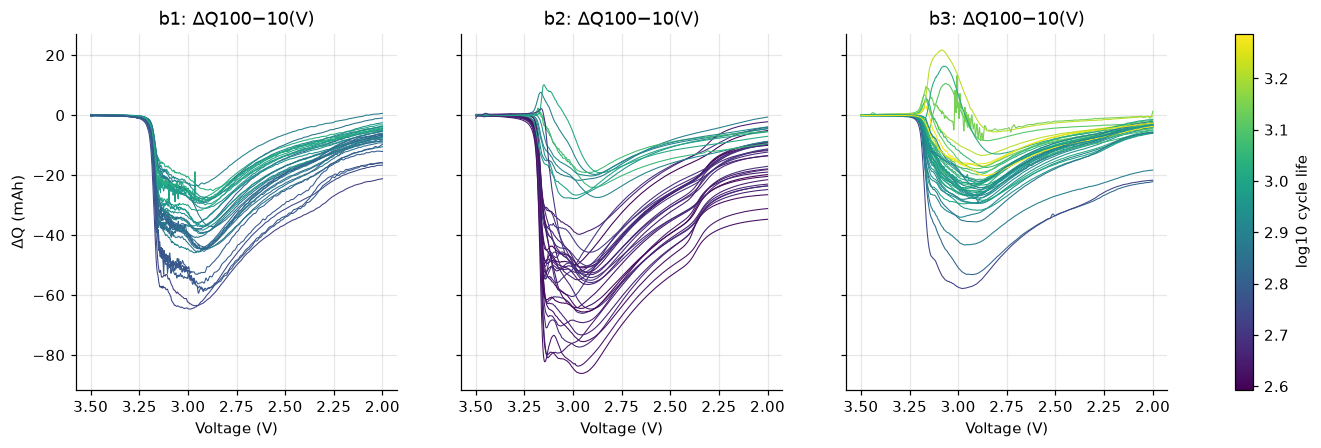

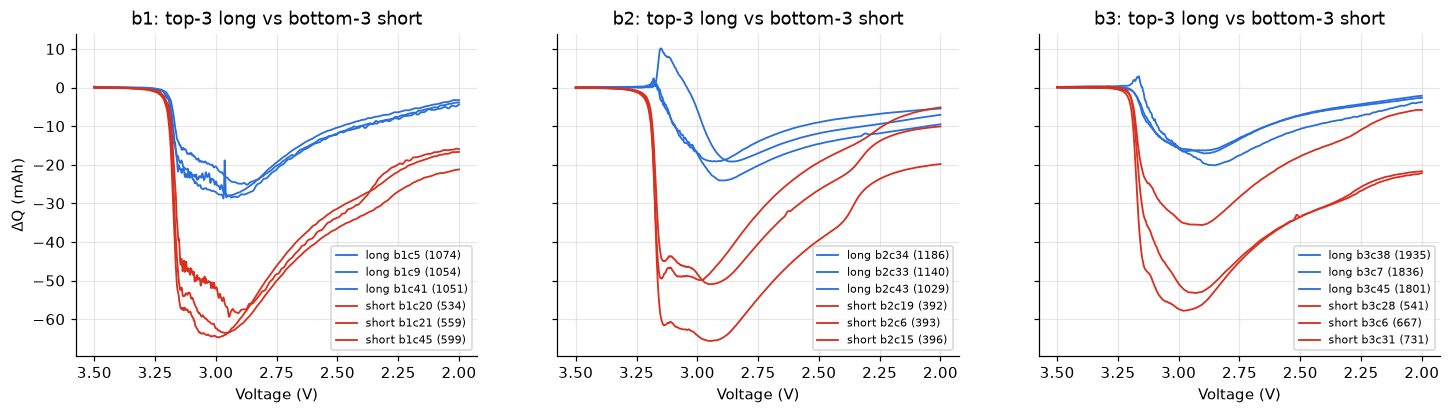

              b1     b2     b3    all
dQ_logvar -0.844 -0.918 -0.762 -0.897
dQ_logmin -0.821 -0.901 -0.744 -0.876
dQ_mean    0.798  0.791  0.720  0.852
dQ_skew   -0.434 -0.126  0.188 -0.028
dQ_kurt   -0.004 -0.662  0.260 -0.008
{'b1': [np.float64(-0.297), np.float64(1.762)], 'b2': [np.float64(-0.328), np.float64(1.547)], 'b3': [np.float64(-0.309), np.float64(1.712)]} {'b1': 635.0033166146311, 'b2': 496.25826197434907, 'b3': 622.4457112987976} {'b2': 43.58974358974359, 'b3': 47.72727272727273} {'b1': 2.93, 'b2': 2.96, 'b3': 2.9}


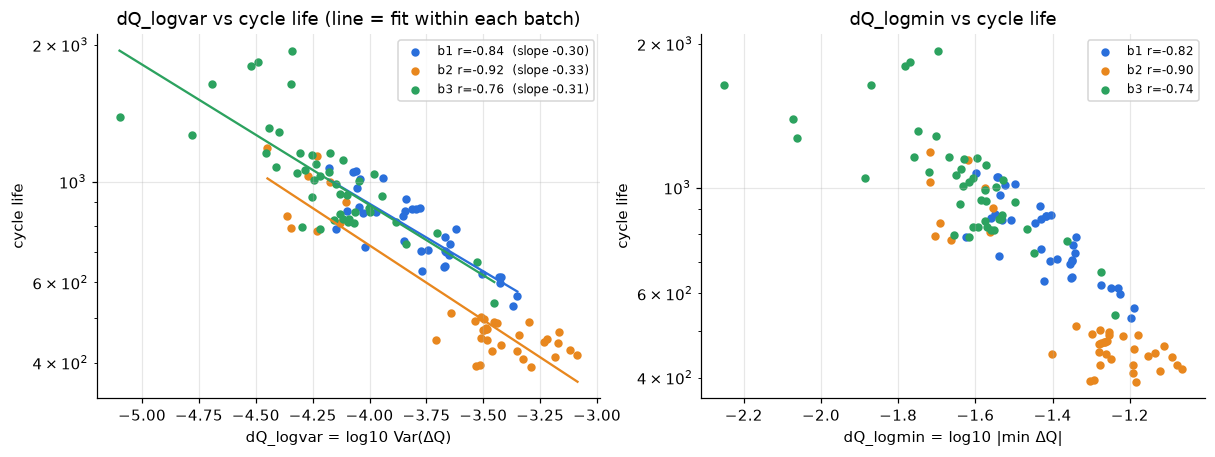

In [7]:
V = cells[0]['vdlin'] if cells[0]['vdlin'] is not None else np.linspace(3.5, 2.0, 1000)
dqc = lambda c: (c['qdlin'][99] - c['qdlin'][9]) * 1000
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for a, t in zip(ax, B):
    for c in [c for c in cells if c['batch'] == t]:
        a.plot(V, dqc(c), color=cm(norm(np.log10(c['life']))), lw=.7)
    a.set(title=f'{t}: ΔQ100−10(V)', xlabel='Voltage (V)'); a.invert_xaxis()
ax[0].set_ylabel('ΔQ (mAh)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm), ax=ax, label='log10 cycle life'); save('Q3_dQ_curves')
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
LS = {}
for a, t in zip(ax, B):
    d = F[F.batch == t]
    for keys, col, lab in ((d.nlargest(3, 'life').key, '#2a6fdb', 'long'), (d.nsmallest(3, 'life').key, '#d7301f', 'short')):
        mins = []
        for k in keys:
            c = next(c for c in cells if c['key'] == k); a.plot(V, dqc(c), color=col, lw=1.2, label=f"{lab} {k} ({int(c['life'])})")
            mins.append(dqc(c).min())
        LS[(t, lab)] = (np.min(mins), np.max(mins))
    a.invert_xaxis(); a.legend(fontsize=7); a.set(title=f'{t}: top-3 long vs bottom-3 short', xlabel='Voltage (V)')
ax[0].set_ylabel('ΔQ (mAh)'); save('Q3_long_short')
ST['q3_long_short_min'] = {f'{t}_{l}': [round(v[0], 1), round(v[1], 1)] for (t, l), v in LS.items()}
F['dQ_vmin'] = [V[np.argmin(dqc(c))] for c in cells]
ST['q3_vmin'] = F.groupby('batch').dQ_vmin.median().round(2).to_dict()
DQ = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'dQ_kurt']
q3 = pd.DataFrame({**{t: [r_(F[F.batch == t][f], F[F.batch == t].log_life) for f in DQ] for t in B},
                   'all': [r_(F[f], F.log_life) for f in DQ]}, index=DQ).round(3)
print(q3); ST['q3_r'] = q3.to_dict()
ST['q3_spear_logvar'] = {t: spearmanr(F[F.batch == t].dQ_logvar, F[F.batch == t].log_life)[0] for t in B}
# 배치별로 각각 맞춘 직선 (기술 통계, 배치 간 평가 아님)
fits = {t: np.polyfit(F[F.batch == t].dQ_logvar, F[F.batch == t].log_life, 1) for t in B}
ST['q3_fits'] = {t: [round(v, 3) for v in fits[t]] for t in B}
xx = -3.5; ST['q3_life_at_-3.5'] = {t: float(10 ** np.polyval(fits[t], xx)) for t in B}
b1r = (F[F.batch == 'b1'].dQ_logvar.min(), F[F.batch == 'b1'].dQ_logvar.max())
ST['q3_b1_range'] = b1r
ST['q3_outside_b1'] = {t: float(((F[F.batch == t].dQ_logvar < b1r[0]) | (F[F.batch == t].dQ_logvar > b1r[1])).mean() * 100) for t in ['b2', 'b3']}
ST['q3_logvar_dist'] = F.groupby('batch').dQ_logvar.agg(['min', 'median', 'max']).round(2).to_dict('index')
print(ST['q3_fits'], ST['q3_life_at_-3.5'], ST['q3_outside_b1'], ST['q3_vmin'])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for t in B:
    d = F[F.batch == t]
    ax[0].scatter(d.dQ_logvar, d.life, c=BC[t], s=20, label=f'{t} r={r_(d.dQ_logvar, d.log_life):.2f}  (slope {fits[t][0]:.2f})')
    xs = np.linspace(d.dQ_logvar.min(), d.dQ_logvar.max(), 10); ax[0].plot(xs, 10 ** np.polyval(fits[t], xs), c=BC[t], lw=1.5)
    ax[1].scatter(d.dQ_logmin, d.life, c=BC[t], s=20, label=f'{t} r={r_(d.dQ_logmin, d.log_life):.2f}')
ax[0].set(yscale='log', title='dQ_logvar vs cycle life (line = fit within each batch)', xlabel='dQ_logvar = log10 Var(ΔQ)', ylabel='cycle life'); ax[0].legend(fontsize=8)
ax[1].set(yscale='log', title='dQ_logmin vs cycle life', xlabel='dQ_logmin = log10 |min ΔQ|', ylabel='cycle life'); ax[1].legend(fontsize=8)
save('Q3_dQ_scatter')

## Q4. 충전 조건(C-rate)과 수명의 관계는?

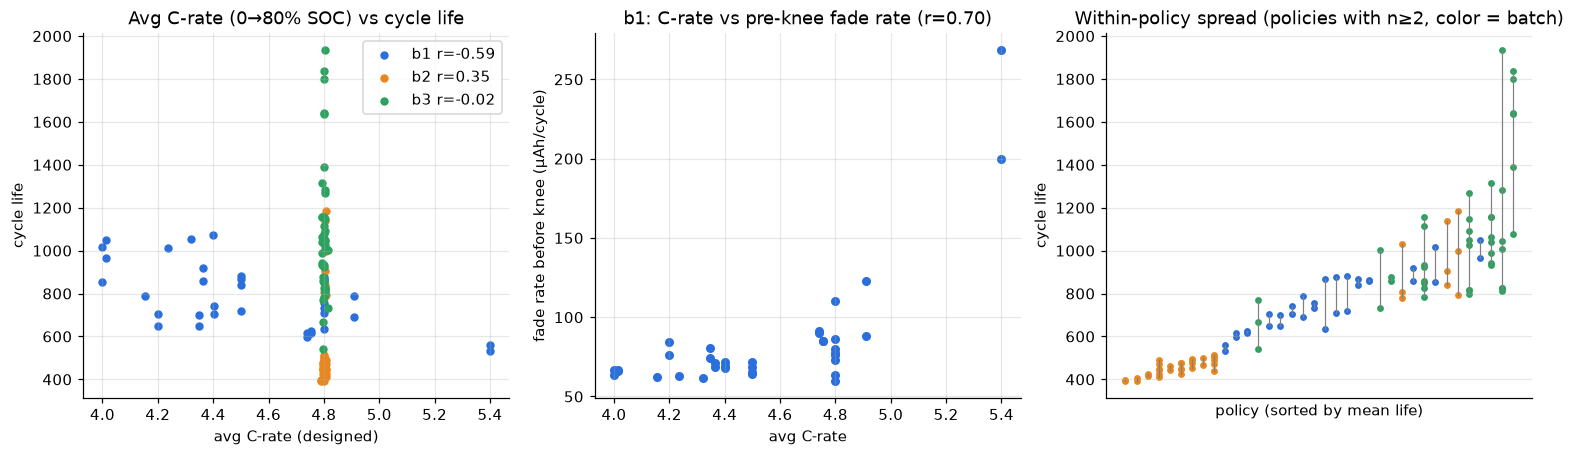

{
"r_crate_life": {
"b1": -0.5938924863405892,
"b2": 0.3496047855946868,
"b3": -0.017460482445006628
},
"avgC_std": {
"b1": 0.3513751304570127,
"b2": 0.004140870173752431,
"b3": 0.004847503977364995
},
"avgC_range": {
"b1": [
4.0,
5.4
],
"b2": [
4.790419161676647,
4.8068669527897
],
"b3": [
4.7936687394007915,
4.813157894736842
]
},
"r_crate_fade_b1": 0.6961316950758596,
"r_c1_fade_b1": -0.16331332794019626,
"r_crate_temp": {
"b1": -0.1986251465604851,
"b2": 0.13650251086667403,
"b3": -0.003445003978011292
},
"r_temp_life": {
"b1": -0.15606695439152488,
"b2": 0.39330635718880613,
"b3": -0.014681850839275729
},
"policy_R2": {
"b1": 0.8945052462559324,
"b2": 0.9415079185025671,
"b3": 0.5749126447281567
},
"n_policy": {
"b1": 20,
"b2": 12,
"b3": 8
},
"maxmin_max": 2.38,
"maxmin_median": 1.105,
"n_policy_ge2": 36,
"fast_mean": 736.4,
"slow_mean": 899.5555555555555,
"fast_n": 10,
"slow_n": 9,
"r_charget": {
"b1": 0.5748612653360105,
"b2": -0.941544894747006,
"b3": 0.6007640278282296
},
"r_c

In [8]:
g = F.groupby(['batch', 'policy']).life
P_ = pd.DataFrame({'n': g.size(), 'mean': g.mean(), 'min': g.min(), 'max': g.max()}).reset_index()
P_['max/min'] = (P_['max'] / P_['min']).round(2)
P2 = P_[P_.n >= 2].sort_values('mean').reset_index(drop=True)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
for t in B:
    d = F[F.batch == t]
    ax[0].scatter(d.avgC_80, d.life, c=BC[t], s=20, label=f'{t} r={r_(d.avgC_80, d.log_life):.2f}')
ax[0].set(title='Avg C-rate (0→80% SOC) vs cycle life', xlabel='avg C-rate (designed)', ylabel='cycle life'); ax[0].legend()
d1 = F[F.batch == 'b1']
ax[1].scatter(d1.avgC_80, -d1.slope_pre, c=BC['b1'], s=24)
ax[1].set(title=f'b1: C-rate vs pre-knee fade rate (r={r_(d1.avgC_80, -d1.slope_pre):.2f})', xlabel='avg C-rate', ylabel='fade rate before knee (µAh/cycle)')
for i, r in P2.iterrows():
    d = F[(F.batch == r.batch) & (F.policy == r.policy)]
    ax[2].plot([i, i], [r['min'], r['max']], c='gray', lw=.8); ax[2].scatter([i] * len(d), d.life, c=BC[r.batch], s=12)
ax[2].set(title='Within-policy spread (policies with n≥2, color = batch)', xlabel='policy (sorted by mean life)', ylabel='cycle life'); ax[2].set_xticks([])
save('Q4_crate')
r_c = {t: r_(F[F.batch == t].avgC_80, F[F.batch == t].log_life) for t in B}
r2 = {}
for t in B:
    d = F[F.batch == t]; m = d.groupby('policy').log_life.transform('mean')
    r2[t] = 1 - ((d.log_life - m) ** 2).sum() / ((d.log_life - d.log_life.mean()) ** 2).sum()
hi = d1[d1.avgC_80 >= d1.avgC_80.quantile(.75)].life; lo = d1[d1.avgC_80 <= d1.avgC_80.quantile(.25)].life
b2n = F[(F.batch == 'b2') & (F.newstruct == 0)]
ST['q4'] = dict(r_crate_life=r_c, avgC_std={t: F[F.batch == t].avgC_80.std() for t in B},
                avgC_range={t: [F[F.batch == t].avgC_80.min(), F[F.batch == t].avgC_80.max()] for t in B},
                r_crate_fade_b1=r_(d1.avgC_80, -d1.slope_pre), r_c1_fade_b1=r_(d1.C1, -d1.slope_pre),
                r_crate_temp={t: r_(F[F.batch == t].avgC_80, F[F.batch == t].Tavg_mean) for t in B},
                r_temp_life={t: r_(F[F.batch == t].Tavg_mean, F[F.batch == t].log_life) for t in B},
                policy_R2=r2, n_policy={t: F[F.batch == t].policy.nunique() for t in B},
                maxmin_max=float(P2['max/min'].max()), maxmin_median=float(P2['max/min'].median()), n_policy_ge2=len(P2),
                fast_mean=hi.mean(), slow_mean=lo.mean(), fast_n=len(hi), slow_n=len(lo),
                r_charget={t: r_(F[F.batch == t].chargetime_2_6, F[F.batch == t].log_life) for t in B},
                r_charget_b2_normal=r_(b2n.chargetime_2_6, b2n.log_life), r_charget_IR_b2=r_(F[F.batch == 'b2'].chargetime_2_6, F[F.batch == 'b2'].IR_2),
                chargetime_std={t: F[F.batch == t].chargetime_2_6.std() for t in B},
                chargetime_ns_b2=F[F.batch == 'b2'].groupby('newstruct').chargetime_2_6.mean().to_dict(),
                b1_policy_rank=F[F.batch == 'b1'].groupby('policy').life.mean().sort_values().round(0).to_dict())
print(json.dumps({k: v for k, v in ST['q4'].items() if k != 'b1_policy_rank'}, default=float, indent=0, ensure_ascii=False))
print(P2.to_string())

## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

                    b1     b2     b3    all  sign_same  min|r|
dQ_logvar       -0.844 -0.918 -0.762 -0.897       True   0.762
dQ_logmin       -0.821 -0.901 -0.744 -0.876       True   0.744
dQ_mean          0.798  0.791  0.720  0.852       True   0.720
avgC_80         -0.594  0.350 -0.017 -0.155      False   0.017
chargetime_2_6   0.575 -0.942  0.601  0.226      False   0.575
QD_slope_2_100   0.556 -0.372  0.432 -0.142      False   0.372
QD_100_m10       0.554 -0.244  0.441 -0.116      False   0.244
QD_slope_91_100  0.535  0.303  0.459  0.084       True   0.303
dQ_skew         -0.434 -0.126  0.188 -0.028      False   0.126
IR_min           0.345 -0.574  0.172 -0.422      False   0.172
C2              -0.292 -0.110 -0.125 -0.179       True   0.110
C1              -0.238  0.196  0.018  0.088      False   0.018
Q1              -0.181  0.164  0.520  0.120      False   0.164
Trange_mean     -0.157 -0.240 -0.152 -0.175       True   0.152
QD_2             0.157 -0.217  0.171 -0.592      False 

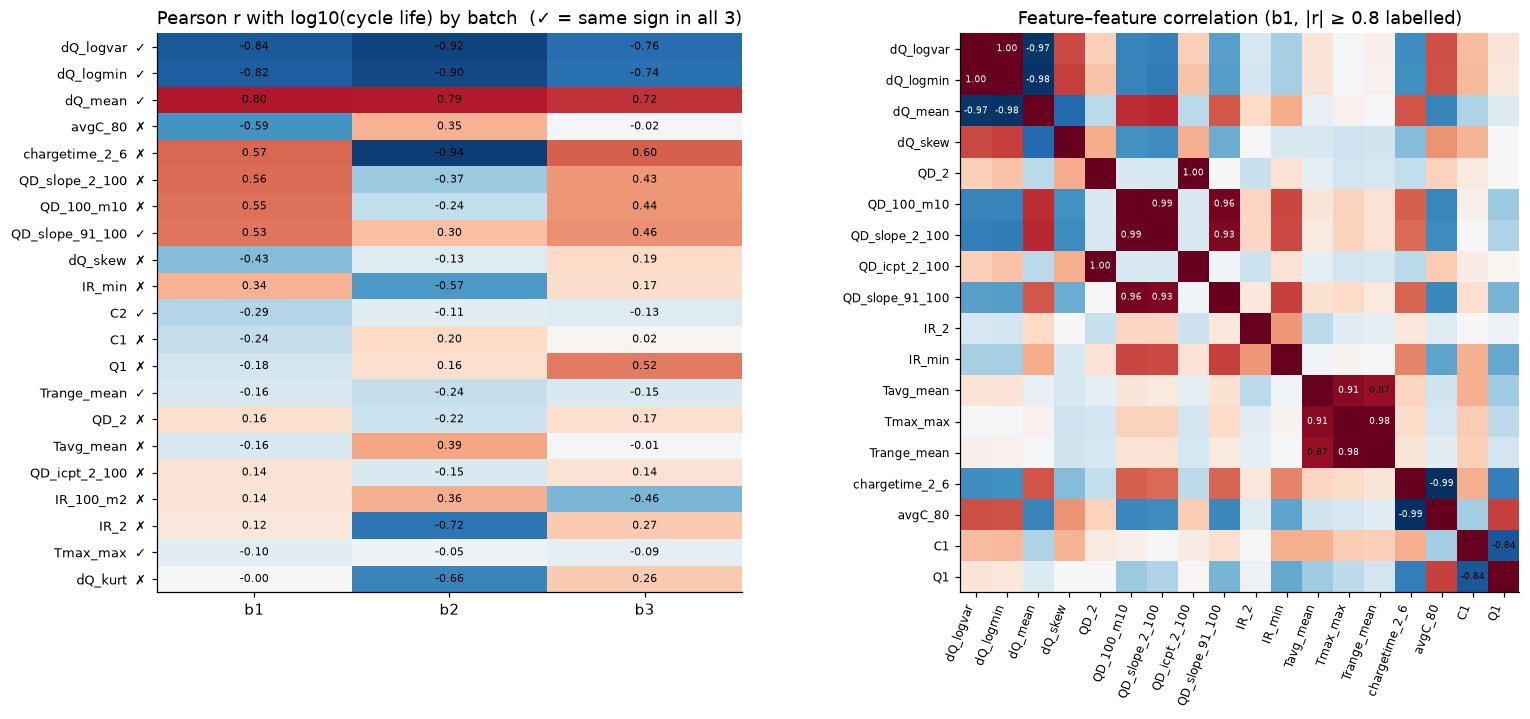

VIF 후보 전체
 dQ_logvar          569.3
dQ_logmin          549.6
avgC_80            376.4
chargetime_2_6     322.0
Tmax_max           143.6
Trange_mean         72.3
dQ_mean             40.4
QD_slope_2_100      23.7
Tavg_mean           22.7
QD_slope_91_100     16.6
QD_2                 3.8
dtype: float64
[('QD_2', 'QD_icpt_2_100', np.float64(0.998)), ('dQ_logvar', 'dQ_logmin', np.float64(0.996)), ('chargetime_2_6', 'avgC_80', np.float64(-0.995)), ('QD_100_m10', 'QD_slope_2_100', np.float64(0.992)), ('Tmax_max', 'Trange_mean', np.float64(0.98)), ('dQ_logmin', 'dQ_mean', np.float64(-0.977)), ('dQ_logvar', 'dQ_mean', np.float64(-0.971)), ('QD_100_m10', 'QD_slope_91_100', np.float64(0.957)), ('QD_slope_2_100', 'QD_slope_91_100', np.float64(0.93)), ('Tavg_mean', 'Tmax_max', np.float64(0.909)), ('Tavg_mean', 'Trange_mean', np.float64(0.875)), ('C1', 'Q1', np.float64(-0.845))]


In [9]:
pr = pd.DataFrame({**{t: F[F.batch == t][FEATS].corrwith(F[F.batch == t].log_life) for t in B}, 'all': F[FEATS].corrwith(F.log_life)})
pr['sign_same'] = (np.sign(pr[B]).nunique(axis=1) == 1); pr['min|r|'] = pr[B].abs().min(axis=1)
pr = pr.reindex(pr['b1'].abs().sort_values(ascending=False).index); print(pr.round(3))
ST['q5_pearson'] = pr.round(3).to_dict('index')
ST['q5_spear'] = pd.DataFrame({t: F[F.batch == t][FEATS].corrwith(F[F.batch == t].log_life, method='spearman') for t in B}).round(3).to_dict('index')
fig, ax = plt.subplots(1, 2, figsize=(17, 6.6), gridspec_kw={'width_ratios': [1, 1.25]})
top = list(pr.index)
M = pr.loc[top, B].values.astype(float)
ax[0].imshow(M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto'); ax[0].grid(False)
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels([f"{f}  {'✓' if pr.loc[f,'sign_same'] else '✗'}" for f in top], fontsize=8.5)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(B)
for i in range(len(top)):
    for j in range(3): ax[0].text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=7.5)
ax[0].set_title('Pearson r with log10(cycle life) by batch  (✓ = same sign in all 3)')
SEL = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'QD_2', 'QD_100_m10', 'QD_slope_2_100', 'QD_icpt_2_100', 'QD_slope_91_100',
       'IR_2', 'IR_min', 'Tavg_mean', 'Tmax_max', 'Trange_mean', 'chargetime_2_6', 'avgC_80', 'C1', 'Q1']
cmx = F[F.batch == 'b1'][SEL].corr()
ax[1].imshow(cmx, cmap='RdBu_r', vmin=-1, vmax=1); ax[1].grid(False)
ax[1].set_xticks(range(len(SEL))); ax[1].set_xticklabels(SEL, rotation=70, ha='right', fontsize=8)
ax[1].set_yticks(range(len(SEL))); ax[1].set_yticklabels(SEL, fontsize=8)
for i in range(len(SEL)):
    for j in range(len(SEL)):
        v = cmx.iloc[i, j]
        if abs(v) >= .8 and i != j: ax[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='w' if abs(v) > .9 else 'k')
ax[1].set_title('Feature–feature correlation (b1, |r| ≥ 0.8 labelled)'); save('Q5_corr')
def vif(X):
    X = (X - X.mean()) / X.std(); o = {}
    for c in X:
        A = np.column_stack([np.ones(len(X)), X.drop(columns=c).values]); y = X[c].values
        b = np.linalg.lstsq(A, y, rcond=None)[0]; r2_ = 1 - ((y - A @ b) ** 2).sum() / ((y - y.mean()) ** 2).sum(); o[c] = 1 / max(1 - r2_, 1e-6)
    return pd.Series(o)
VC = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'QD_2', 'QD_slope_2_100', 'QD_slope_91_100', 'Tavg_mean', 'Tmax_max', 'Trange_mean', 'chargetime_2_6', 'avgC_80']
v = vif(F[F.batch == 'b1'][VC]).round(1).sort_values(ascending=False); print('VIF 후보 전체\n', v); ST['q5_vif'] = v.to_dict()
pairs = [(a, b, cmx.loc[a, b]) for i, a in enumerate(SEL) for b in SEL[i + 1:] if abs(cmx.loc[a, b]) >= .8]
ST['q5_pairs'] = sorted([(a, b, round(r, 3)) for a, b, r in pairs], key=lambda x: -abs(x[2])); print(ST['q5_pairs'])

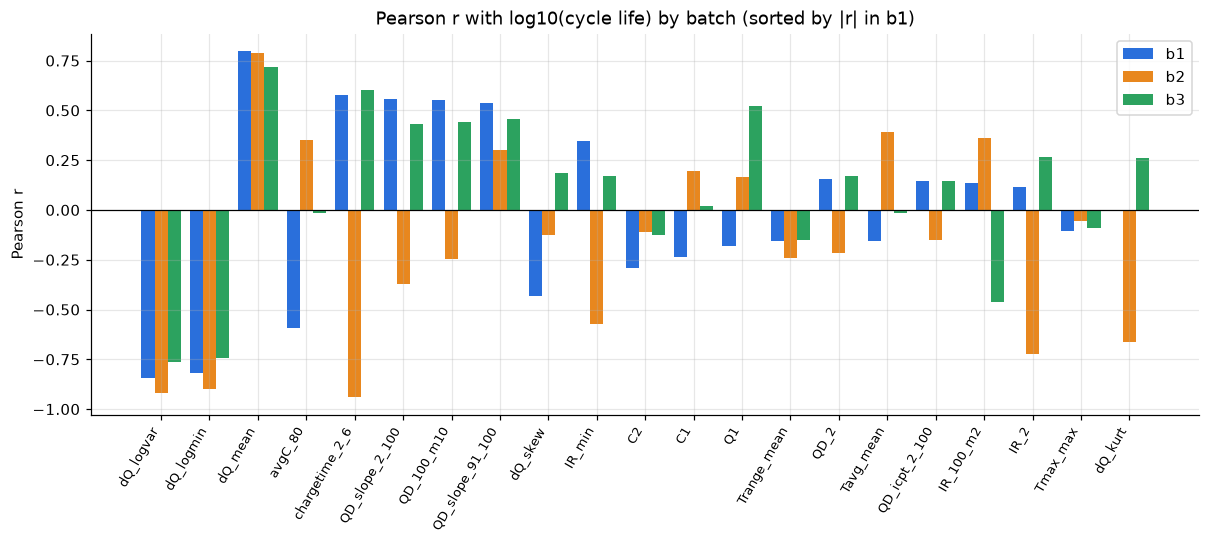

In [10]:
# 피처별 log10 수명과의 Pearson r (배치별 막대) : 10장
fig, ax = plt.subplots(figsize=(13, 4.5)); x = np.arange(len(pr))
for k, t in enumerate(B):
    ax.bar(x + (k - 1) * .27, pr[t], width=.27, color=BC[t], label=t)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(pr.index, rotation=60, ha='right', fontsize=8.5)
ax.set(title='Pearson r with log10(cycle life) by batch (sorted by |r| in b1)', ylabel='Pearson r'); ax.legend()
save('Q5_r_by_batch')

## Feature Selection — 배치 일관성 기준
기준: ① 세 배치에서 부호 동일 ② 세 배치 중 최소 |r| ≥ 0.2 ③ 공선성 그룹(|r| ≥ 0.8)당 대표 1개 ④ 학습 셀 36개 → 피처 소수

In [11]:
cand = pr[(pr.sign_same) & (pr['min|r|'] >= 0.2)].sort_values('min|r|', ascending=False)
print('기준 ①② 통과:\n', cand[B + ['min|r|']].round(3))
FINAL = ['dQ_logvar', 'QD_slope_91_100', 'Trange_mean']
print('최종 피처 VIF (b1):\n', vif(F[F.batch == 'b1'][FINAL]).round(2))
ST['fs_pass'] = cand[B + ['min|r|']].round(3).to_dict('index')
ST['fs_final_vif'] = vif(F[F.batch == 'b1'][FINAL]).round(2).to_dict()
ST['fs_final_corr'] = F[F.batch == 'b1'][FINAL].corr().round(2).to_dict()
F.to_csv(f'{DATA}/features_cycle100.csv', index=False)
FS.to_csv(f'{DATA}/features_sensitivity_b1c0-4.csv', index=False)
json.dump(ST, open(f'{DATA}/eda_stats.json', 'w'), default=lambda o: float(o) if np.isscalar(o) else str(o), ensure_ascii=False, indent=1)
print('DONE')

기준 ①② 통과:
                     b1     b2     b3  min|r|
dQ_logvar       -0.844 -0.918 -0.762   0.762
dQ_logmin       -0.821 -0.901 -0.744   0.744
dQ_mean          0.798  0.791  0.720   0.720
QD_slope_91_100  0.535  0.303  0.459   0.303
최종 피처 VIF (b1):
 dQ_logvar          1.44
QD_slope_91_100    1.45
Trange_mean        1.03
dtype: float64
DONE


## 장표 보조 수치 (DAY 1 PDF v2)
PDF에 쓰인 수치 중 위 셀에서 직접 출력하지 않은 값. 모두 배치별 기술 통계이며, 배치 간 모델 평가는 하지 않는다.

In [12]:
X = {}
# 4장 : describe (IQR, whisker = |Q3 - max|, |Q1 - min|)
d = F.groupby('batch').life
X['q1_describe'] = pd.DataFrame({'mean': d.mean(), 'median': d.median(), 'Q1': d.quantile(.25), 'Q3': d.quantile(.75),
                                 'upper_whisker': d.max() - d.quantile(.75), 'lower_whisker': d.quantile(.25) - d.min()}).round(0).to_dict('index')
b1min, b1max = F[F.batch == 'b1'].life.min(), F[F.batch == 'b1'].life.max()
X['q1_b2_below_b1min_pct'] = float((F[F.batch == 'b2'].life < b1min).mean() * 100)
X['q1_b3_above_b1max_pct'] = float((F[F.batch == 'b3'].life > b1max).mean() * 100)
# 3장 : b2는 EOL 이후 추가 측정
ex = pd.Series([len(c['summary']['QDischarge']) - c['life'] for c in cells if c['batch'] == 'b2'])
X['b2_after_eol'] = dict(min=ex.min(), median=ex.median(), max=ex.max())
# 6장 : cycle 2~100 QD 범위
X['q2_qd_2_100_range'] = [float(min(c['qd_s'][1:100].min() for c in cells)), float(max(c['qd_s'][1:100].max() for c in cells))]
# 8장 : dQ_logvar가 b1 범위 밖인 비율
lo, hi = F[F.batch == 'b1'].dQ_logvar.agg(['min', 'max'])
X['q3_outside_b1_pct'] = {t: float(((F[F.batch == t].dQ_logvar < lo) | (F[F.batch == t].dQ_logvar > hi)).mean() * 100) for t in ['b2', 'b3']}
# 10장 : b1 |r| > 0.5 피처 중 b2 부호 반전
big = pr[pr['b1'].abs() > 0.5]
X['q5_b1_strong'] = list(big.index); X['q5_b1_strong_flip_b2'] = list(big[np.sign(big['b1']) != np.sign(big['b2'])].index)
for k, v in X.items(): print(k, v)
ST['pdf_extra'] = X
json.dump(ST, open(f'{DATA}/eda_stats.json', 'w'), default=lambda o: float(o) if np.isscalar(o) else str(o), ensure_ascii=False, indent=1)

q1_describe {'b1': {'mean': 788.0, 'median': 772.0, 'Q1': 681.0, 'Q3': 872.0, 'upper_whisker': 202.0, 'lower_whisker': 147.0}, 'b2': {'mean': 566.0, 'median': 472.0, 'Q1': 440.0, 'Q3': 508.0, 'upper_whisker': 678.0, 'lower_whisker': 48.0}, 'b3': {'mean': 1060.0, 'median': 1006.0, 'Q1': 828.0, 'Q3': 1155.0, 'upper_whisker': 780.0, 'lower_whisker': 287.0}}
q1_b2_below_b1min_pct 76.92307692307693
q1_b3_above_b1max_pct 36.36363636363637
b2_after_eol {'min': np.float64(15.0), 'median': np.float64(22.0), 'max': np.float64(66.0)}
q2_qd_2_100_range [1.0340093, 1.1166337]
q3_outside_b1_pct {'b2': 43.58974358974359, 'b3': 47.72727272727273}
q5_b1_strong ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'avgC_80', 'chargetime_2_6', 'QD_slope_2_100', 'QD_100_m10', 'QD_slope_91_100']
q5_b1_strong_flip_b2 ['avgC_80', 'chargetime_2_6', 'QD_slope_2_100', 'QD_100_m10']
